<a href="https://colab.research.google.com/github/liuxiaohu0511/lance-demo/blob/develop/lance_blob_api.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
pip install pylance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 MB 17.8 MB/s eta 0:00:00


In [6]:
import shutil
import lance
import numpy as np
import pandas as pd
import pyarrow as pa
import duckdb

与其他数据格式不同，在大型的多模态数据中，Lance 列式格式将大型二进制对象（blob）视为一等公民。Lance 提供高级 API 来存储和检索 Lance 数据集中的大型二进制对象。



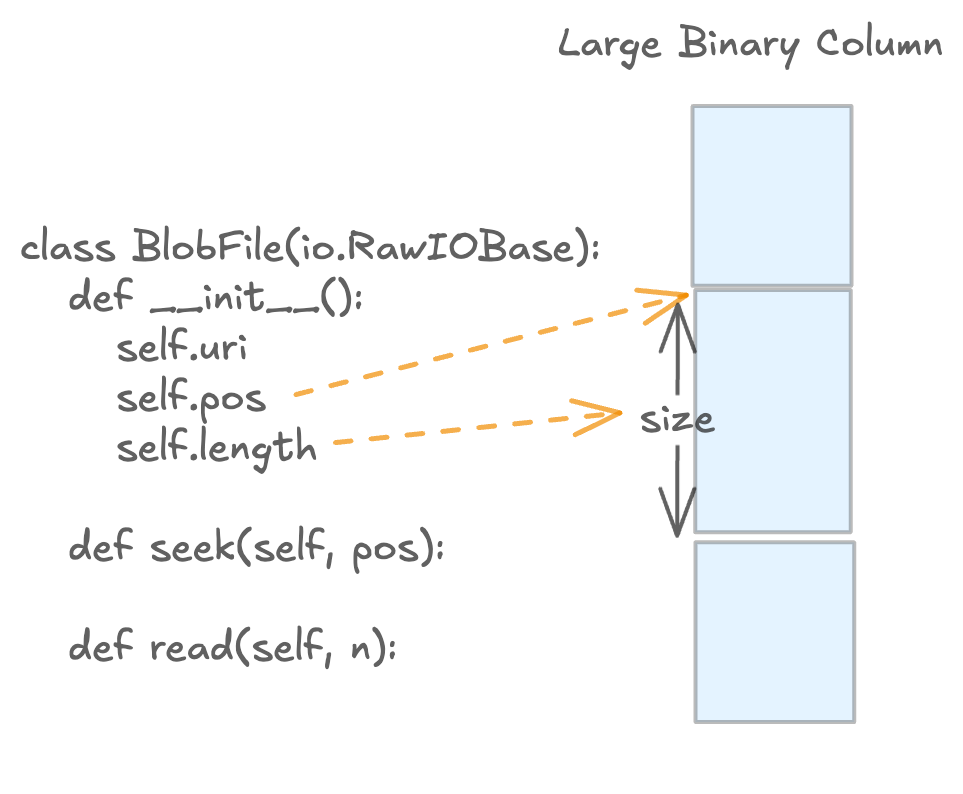

Lance 使用 lance.BlobFile 服务大型的二进制数据，这是一个类似文件的对象，可以懒加载地读取大型二进制对象。

要创建一个包含大型 blob 数据的 Lance 数据集，你可以通过添加元数据 lance-encoding:blob 到 true 将一个大型二进制列标记为 blob 列。

In [2]:
import pyarrow as pa

schema = pa.schema(
    [
        pa.field("id", pa.int64()),
        pa.field("video",
            pa.large_binary(),
            metadata={"lance-encoding:blob": "true"}
        ),
    ]
)

要将 blob 数据写入 Lance 数据集，创建一个具有 blob 模式的 PyArrow 表并使用lance.write_dataste

In [7]:
import lance

# First, download a sample video file for testing
# wget https://www.learningcontainer.com/wp-content/uploads/2020/05/sample-mp4-file.mp4
import urllib.request
urllib.request.urlretrieve(
    "https://www.learningcontainer.com/wp-content/uploads/2020/05/sample-mp4-file.mp4",
    "sample_video.mp4"
)

# Then read the video file content
with open("sample_video.mp4", 'rb') as f:
    video_data = f.read()

# Create table with blob data
table = pa.table({
    "id": [1],
    "video": [video_data],
}, schema=schema)

# Write to Lance dataset
ds = lance.write_dataset(
    table,
    "./youtube.lance",
    schema=schema
)

要从 Lance 数据集中获取 blob，可以使用 lance.dataset.LanceDataset.take_blobs

例如，使用 BlobFile 轻松从视频文件中提取帧，而无需将整个视频加载到内存中。

In [8]:
pip install av

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 22.0 MB/s eta 0:00:00


<av.VideoStream #0 h264, yuv420p 320x240 at 0x7f844700ba10>


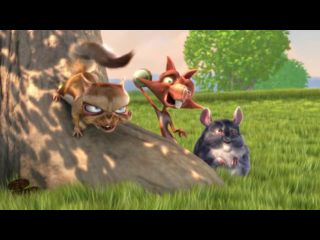

In [12]:
import av # pip install av  # 用于视频解码和处理（需要通过 pip install av 安装）
import lance  # 用于操作 Lance 数据集
from IPython.display import clear_output

ds = lance.dataset("./youtube.lance") # 加载当前目录下名为 youtube.lance 的 Lance 数据集，该数据集应包含一个名为 video 的字段，存储视频文件的二进制数据（blob）
start_time, end_time = 500, 1000 # 指定要提取视频帧的时间范围：从第 500 秒到第 1000 秒
# Get blob data from the first row (id=0)
blobs = ds.take_blobs("video", ids=[0]) #从数据集的 video 字段中，读取 id=0 的行对应的二进制数据（视频文件的原始字节）。blobs 是一个列表，这里只取了一行，所以 blobs[0] 就是该视频的二进制内容
with av.open(blobs[0]) as container: # 将二进制视频数据作为输入，创建一个视频容器（类似打开本地视频文件），with 语句确保处理完后自动关闭资源
    stream = container.streams.video[0] #获取视频流（一个视频文件可能包含多个流，这里取第一个视频流）
    # print(stream)
    stream.codec_context.skip_frame = "NONKEY" #设置解码时只处理关键帧（I 帧），非关键帧（如 P 帧、B 帧）会被跳过，加快处理速度（关键帧可独立解码，无需依赖其他帧）

    start_time = start_time / stream.time_base #视频流的时间单位由 stream.time_base 定义（通常是分数，如 1/1000 表示毫秒），需将 start_time 和 end_time（秒）转换为视频流的内部时间单位
    start_time = start_time.as_integer_ratio()[0] #将视频定位到 start_time 对应的位置，从该点开始解码
    end_time = end_time / stream.time_base
    container.seek(start_time, stream=stream)

    for frame in container.decode(stream): #开始解码视频流，逐帧返回视频帧
        if frame.time > end_time: #当帧的时间超过 end_time 时，停止解码，退出循环
            break
        display(frame.to_image()) #将视频帧转换为图像并显示（需在 Jupyter 等支持 display 的环境中运行）
        clear_output(wait=True)
  # 从 Lance 数据集读取视频二进制数据 → 2. 用 av 库解码视频 → 3. 定位到指定时间范围（500-1000 秒）→ 4. 提取并显示该范围内的关键帧。